# Matrices de Corrélation — Avant & Après Preprocessing
### Dataset : Retail Customers — Prédiction du Churn
---
Ce notebook génère trois visualisations :
1. **Heatmap complète AVANT preprocessing** — variables numériques brutes
2. **Heatmap complète APRÈS preprocessing** — variables continues post-traitement
3. **Barplot comparatif** — corrélation de chaque feature avec la cible `Churn`, avant vs après


In [3]:
# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

print("✅ Imports OK")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 55.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 74.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 88.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 60.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 90.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
✅ Imports OK


In [4]:
# ─────────────────────────────────────────────
# PARAMÈTRES DU PROJET
# ─────────────────────────────────────────────

# ⚠️  Modifiez ce chemin selon votre environnement
DATA_PATH = "data/raw/retail_customers_COMPLETE_CATEGORICAL.csv"

TARGET_COL   = "Churn"
RANDOM_STATE = 42
TEST_SIZE    = 0.2

COLS_TO_DROP = [
    "CustomerID", "LastLoginIP", "RegistrationDate", "NewsletterSubscribed",
    "UniqueInvoices", "CancelledTransactions", "Country", "PreferredMonth",
    # Data leakage
    "ChurnRiskCategory", "CustomerType", "RFMSegment",
    "Recency", "Age", "FirstPurchaseDaysAgo", "CustomerTenureDays",
    "LoyaltyLevel", "UniqueCountries",
]

NUMERIC_COLS_STORED_AS_OBJECT = [
    "MonetaryTotal", "MonetaryAvg", "MonetaryStd", "MonetaryMin", "MonetaryMax",
    "AvgQuantityPerTransaction", "AvgDaysBetweenPurchases",
    "AvgProductsPerTransaction", "AvgLinesPerInvoice",
]

ORDINAL_MAPPINGS = {
    "SpendingCategory":  ["Low", "Medium", "High", "VIP"],
    "BasketSizeCategory": ["Petit", "Moyen", "Grand"],
}

NOMINAL_COLS = [
    "PreferredTimeOfDay", "Region", "WeekendPreference", "ProductDiversity",
    "Gender", "AccountStatus", "AgeCategory",
]

COLS_REMOVE_MULTI = [
    "MonetaryStd", "MonetaryMin", "MinQuantity", "WeekendPurchaseRatio",
    "UniqueProducts", "AvgProductsPerTransaction", "MaxQuantity", "CancellationRate",
]

print("✅ Paramètres chargés")


✅ Paramètres chargés


In [5]:
# ─────────────────────────────────────────────
# CHARGEMENT DU DATASET
# Le fichier CSV contient des marqueurs de conflits Git (<<<<<<< HEAD).
# Ce bloc les supprime automatiquement avant lecture.
# ─────────────────────────────────────────────
import io

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = f.read()

# Détection et nettoyage des conflits Git
if "<<<<<<< HEAD" in raw:
    lines = raw.splitlines()
    in_conflict = False
    keep_head   = False
    clean_lines = []
    for line in lines:
        if line.startswith("<<<<<<< "):
            in_conflict = True
            keep_head   = True
            continue
        elif line.startswith("======="):
            keep_head = False
            continue
        elif line.startswith(">>>>>>> "):
            in_conflict = False
            keep_head   = False
            continue
        if not in_conflict or keep_head:
            clean_lines.append(line)
    raw = "\n".join(clean_lines)
    print("⚠️  Conflits Git détectés et nettoyés automatiquement.")

df_raw = pd.read_csv(io.StringIO(raw))
print(f"✅ Dataset chargé : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")
print(f"   Distribution cible → {df_raw[TARGET_COL].value_counts().to_dict()}")
df_raw.head(3)


⚠️  Conflits Git détectés et nettoyés automatiquement.
✅ Dataset chargé : 4372 lignes × 52 colonnes
   Distribution cible → {0: 2918, 1: 1454}


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0


In [6]:
# ─────────────────────────────────────────────
# DONNÉES AVANT PREPROCESSING
# On retire uniquement les colonnes de data leakage,
# puis on garde toutes les variables numériques brutes.
# ─────────────────────────────────────────────
cols_to_drop_present = [c for c in COLS_TO_DROP if c in df_raw.columns]
df_before = df_raw.drop(columns=cols_to_drop_present)

# Sélection des colonnes numériques brutes (inclut Churn)
df_before_num = df_before.select_dtypes(include="number")

print(f"Variables numériques AVANT preprocessing : {df_before_num.shape[1]}")
print(f"Colonnes : {df_before_num.columns.tolist()}")


Variables numériques AVANT preprocessing : 25
Colonnes : ['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'PreferredDayOfWeek', 'PreferredHour', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'NegativeQuantityCount', 'ZeroPriceCount', 'ReturnRatio', 'TotalTransactions', 'AvgLinesPerInvoice', 'SupportTicketsCount', 'SatisfactionScore', 'Churn']


In [7]:
# ─────────────────────────────────────────────
# PIPELINE DE PREPROCESSING COMPLET
# ─────────────────────────────────────────────
df_after = df_raw.copy()

# 1. Suppression des colonnes inutiles / leakage
df_after.drop(columns=cols_to_drop_present, inplace=True, errors="ignore")

# 2. Coercition numérique
for col in NUMERIC_COLS_STORED_AS_OBJECT:
    if col in df_after.columns:
        df_after[col] = pd.to_numeric(df_after[col], errors="coerce")

# 3. Correction des valeurs aberrantes
if "SupportTicketsCount" in df_after.columns:
    df_after["SupportTicketsCount"] = df_after["SupportTicketsCount"].clip(lower=0)
if "SatisfactionScore" in df_after.columns:
    df_after["SatisfactionScore"] = df_after["SatisfactionScore"].clip(lower=0, upper=10)

# 4. Feature Engineering
if "MonetaryTotal" in df_after.columns and "Frequency" in df_after.columns:
    df_after["AvgBasketValue"] = df_after["MonetaryTotal"] / (df_after["Frequency"] + 1)
if "NegativeQuantityCount" in df_after.columns and "TotalTransactions" in df_after.columns:
    df_after["CancellationRate"] = df_after["NegativeQuantityCount"] / (df_after["TotalTransactions"] + 1)
if "SatisfactionScore" in df_after.columns and "SupportTicketsCount" in df_after.columns:
    df_after["EngagementScore"] = df_after["SatisfactionScore"] / (df_after["SupportTicketsCount"] + 1)

# 5. Train/Test split stratifié
X = df_after.drop(columns=[TARGET_COL])
y = df_after[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# 6. Imputation (fit sur train uniquement)
num_cols    = X_train.select_dtypes(include="number").columns.tolist()
num_missing = [c for c in num_cols if X_train[c].isnull().any()]
if num_missing:
    imp_num = SimpleImputer(strategy="median")
    X_train[num_missing] = imp_num.fit_transform(X_train[num_missing])

cat_cols    = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
cat_missing = [c for c in cat_cols if X_train[c].isnull().any()]
if cat_missing:
    imp_cat = SimpleImputer(strategy="most_frequent")
    X_train[cat_missing] = imp_cat.fit_transform(X_train[cat_missing])

# 7. Encodage ordinal
for col, order in ORDINAL_MAPPINGS.items():
    if col in X_train.columns:
        enc = OrdinalEncoder(categories=[order], handle_unknown="use_encoded_value", unknown_value=-1)
        X_train[[col]] = enc.fit_transform(X_train[[col]])

# 8. One-Hot Encoding
nominal_present = [c for c in NOMINAL_COLS if c in X_train.columns]
X_train = pd.get_dummies(X_train, columns=nominal_present, drop_first=False, dtype=int)

# 9. Suppression multicolinéarité
X_train.drop(columns=[c for c in COLS_REMOVE_MULTI if c in X_train.columns], inplace=True)

# 10. Normalisation (StandardScaler)
num_c    = X_train.select_dtypes(include="number").columns.tolist()
binary_c = [c for c in num_c if X_train[c].nunique() <= 2]
to_scale = [c for c in num_c if c not in binary_c]
scaler   = StandardScaler()
X_train[to_scale] = scaler.fit_transform(X_train[to_scale])

# Réattacher la cible pour la corrélation
X_train_churn = X_train.copy()
X_train_churn[TARGET_COL] = y_train.values

# Variables continues uniquement (exclure les OHE binaires)
df_after_num    = X_train_churn.select_dtypes(include="number")
continuous_cols = [c for c in df_after_num.columns if df_after_num[c].nunique() > 2]
df_after_cont   = df_after_num[continuous_cols]

print(f"✅ Preprocessing terminé")
print(f"   Variables continues APRÈS : {df_after_cont.shape[1]}")
print(f"   Colonnes : {df_after_cont.columns.tolist()}")


✅ Preprocessing terminé
   Variables continues APRÈS : 21
   Colonnes : ['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'PreferredDayOfWeek', 'PreferredHour', 'AvgDaysBetweenPurchases', 'UniqueDescriptions', 'NegativeQuantityCount', 'ZeroPriceCount', 'ReturnRatio', 'TotalTransactions', 'AvgLinesPerInvoice', 'SupportTicketsCount', 'SatisfactionScore', 'SpendingCategory', 'BasketSizeCategory', 'AvgBasketValue', 'EngagementScore']


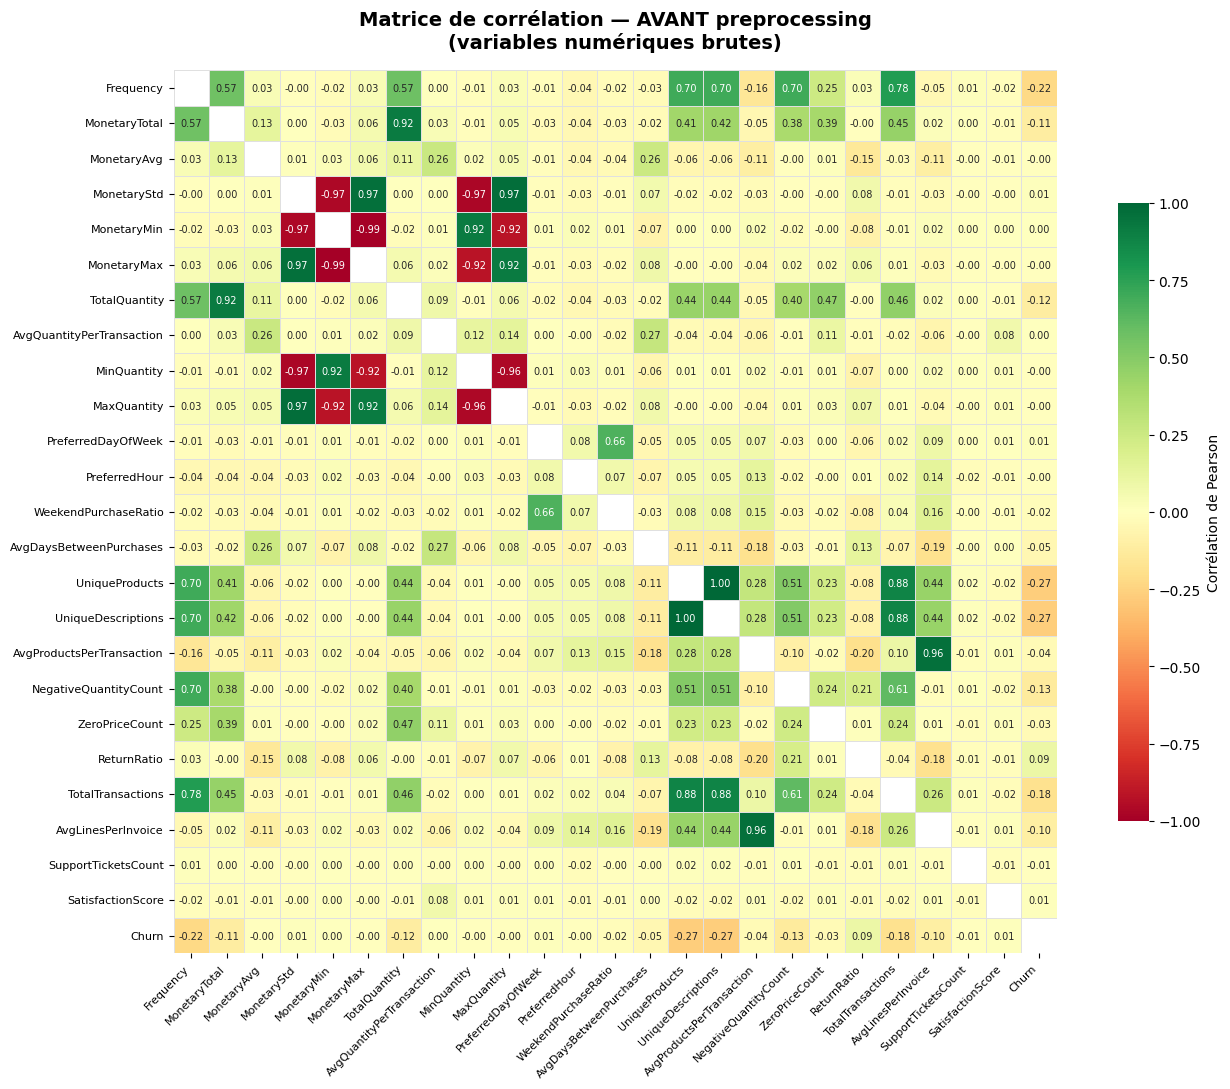

💾 Sauvegardé : corr_avant_preprocessing.png


In [8]:
# ─────────────────────────────────────────────
# FIGURE 1 — HEATMAP CORRÉLATION AVANT PREPROCESSING
# ─────────────────────────────────────────────
corr_avant = df_before_num.corr()

mask = np.zeros_like(corr_avant, dtype=bool)
np.fill_diagonal(mask, True)  # Masquer la diagonale (toujours = 1)

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(
    corr_avant,
    mask=mask,
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor="#e0e0e0",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Corrélation de Pearson"},
    ax=ax
)

ax.set_title(
    "Matrice de corrélation — AVANT preprocessing\n(variables numériques brutes)",
    fontsize=14, fontweight="bold", pad=16
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig("corr_avant_preprocessing.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Sauvegardé : corr_avant_preprocessing.png")


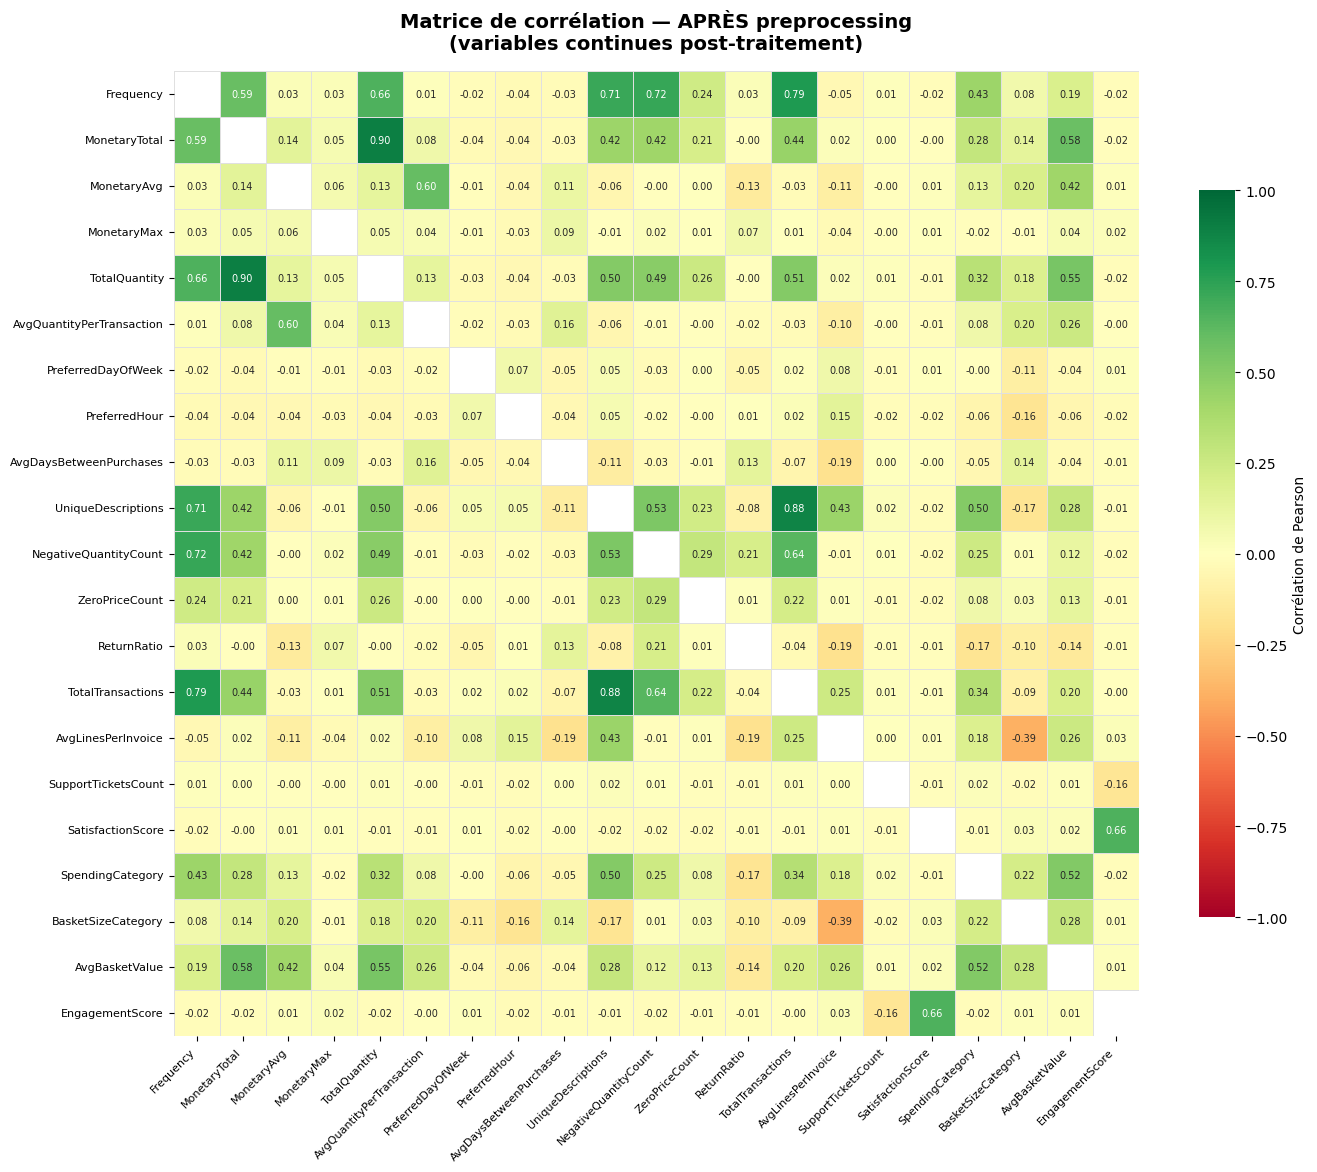

💾 Sauvegardé : corr_apres_preprocessing.png


In [9]:
# ─────────────────────────────────────────────
# FIGURE 2 — HEATMAP CORRÉLATION APRÈS PREPROCESSING
# ─────────────────────────────────────────────
corr_apres = df_after_cont.corr()

mask2 = np.zeros_like(corr_apres, dtype=bool)
np.fill_diagonal(mask2, True)

fig2, ax2 = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_apres,
    mask=mask2,
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor="#e0e0e0",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Corrélation de Pearson"},
    ax=ax2
)

ax2.set_title(
    "Matrice de corrélation — APRÈS preprocessing\n(variables continues post-traitement)",
    fontsize=14, fontweight="bold", pad=16
)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig("corr_apres_preprocessing.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Sauvegardé : corr_apres_preprocessing.png")


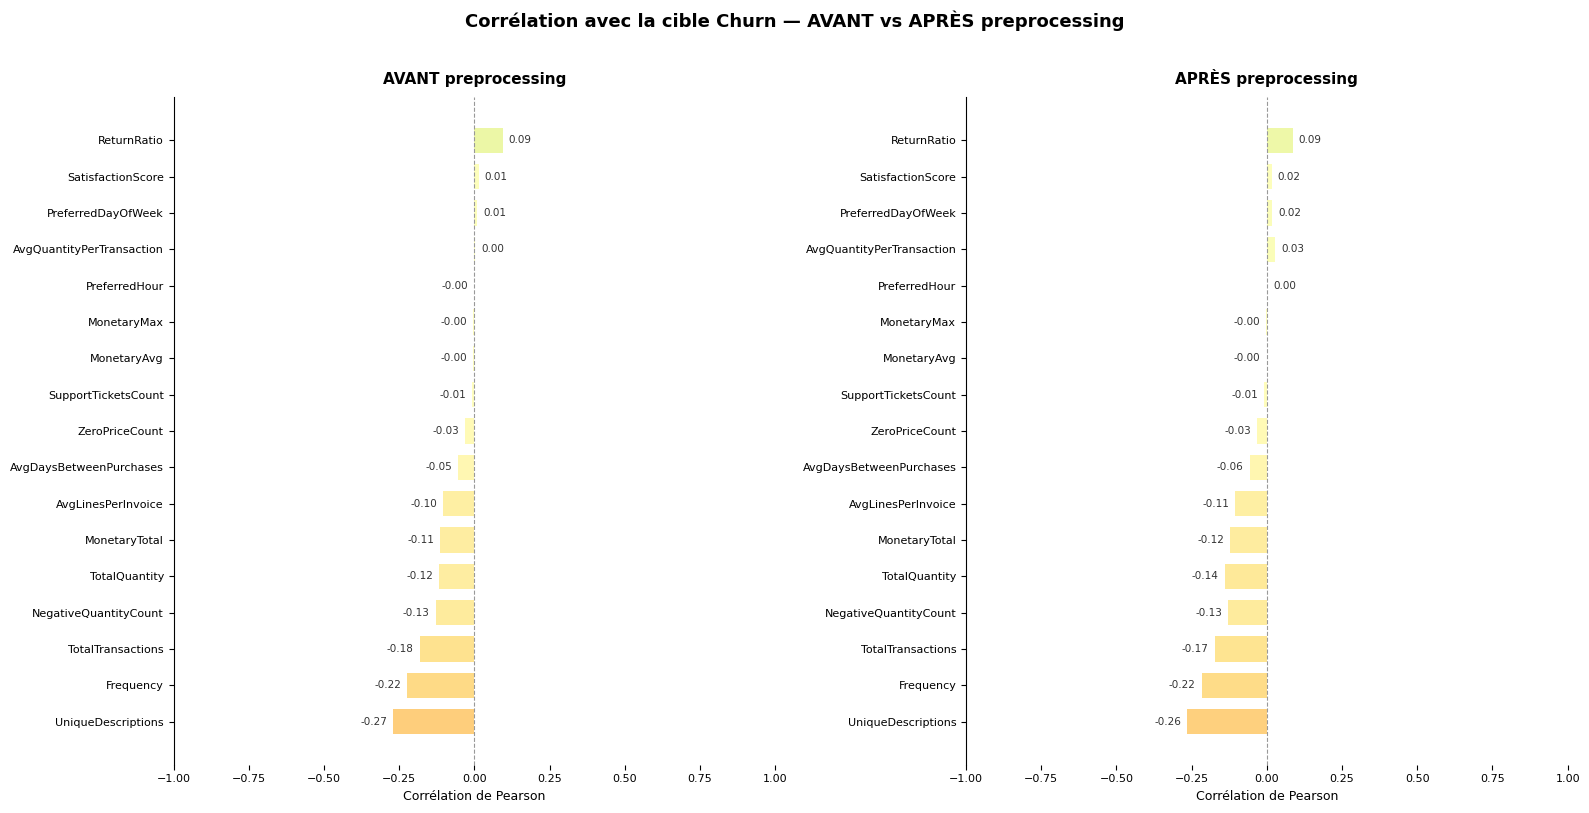

💾 Sauvegardé : corr_churn_avant_apres.png


In [11]:
# ─────────────────────────────────────────────
# FIGURE 3 — CORRÉLATION AVEC CHURN : AVANT vs APRÈS
# ─────────────────────────────────────────────
corr_churn_avant = df_before_num.corr()[TARGET_COL].drop(TARGET_COL).sort_values()
corr_churn_avant = df_before_num.corr()[TARGET_COL].drop(TARGET_COL).sort_values()
corr_churn_apres = df_after_num.corr()[TARGET_COL].drop(TARGET_COL).sort_values()

# Features communes aux deux
common_features = sorted(set(corr_churn_avant.index) & set(corr_churn_apres.index))
cb = corr_churn_avant[common_features].sort_values()
ca = corr_churn_apres[common_features].reindex(cb.index)

# Palette divergente : vert (corrélation positive) / rouge (négative)
cmap_div = plt.cm.RdYlGn

def bar_colors(vals):
    return [cmap_div(0.5 + v / 2) for v in vals]

fig3, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(16, max(8, len(common_features) * 0.38)))
fig3.suptitle(
    "Corrélation avec la cible Churn — AVANT vs APRÈS preprocessing",
    fontsize=13, fontweight="bold", y=1.01
)

for ax, corr_vals, title in [
    (ax_a, cb, "AVANT preprocessing"),
    (ax_b, ca, "APRÈS preprocessing"),
]:
    colors = bar_colors(corr_vals.values)
    bars   = ax.barh(corr_vals.index, corr_vals.values, color=colors, height=0.7, edgecolor="none")
    ax.axvline(0, color="#999", linewidth=0.8, linestyle="--")
    ax.set_xlim(-1, 1)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.set_xlabel("Corrélation de Pearson", fontsize=9)

    # Annotations des valeurs
    for bar, val in zip(bars, corr_vals.values):
        offset = 0.02 if val >= 0 else -0.02
        ha     = "left" if val >= 0 else "right"
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", ha=ha, fontsize=7.5, color="#333")

plt.tight_layout()
plt.savefig("corr_churn_avant_apres.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Sauvegardé : corr_churn_avant_apres.png")


In [12]:
# ─────────────────────────────────────────────
# RÉSUMÉ — TOP 10 CORRÉLATIONS AVEC CHURN
# ─────────────────────────────────────────────
print("=" * 55)
print("TOP 10 corrélations (|r|) avec Churn — AVANT")
print("=" * 55)
top_avant = corr_churn_avant.abs().sort_values(ascending=False).head(10)
for feat, val in top_avant.items():
    sign = "+" if corr_churn_avant[feat] > 0 else "-"
    print(f"  {feat:<35} {sign}{val:.4f}")

print()
print("=" * 55)
print("TOP 10 corrélations (|r|) avec Churn — APRÈS")
print("=" * 55)
top_apres = corr_churn_apres.abs().sort_values(ascending=False).head(10)
for feat, val in top_apres.items():
    sign = "+" if corr_churn_apres[feat] > 0 else "-"
    print(f"  {feat:<35} {sign}{val:.4f}")

print()
print("\n📌 Rappel interprétation :")
print("   r > 0  → la feature augmente quand Churn = 1")
print("   r < 0  → la feature diminue quand Churn = 1")
print("   |r| > 0.3 → corrélation modérée à forte")


TOP 10 corrélations (|r|) avec Churn — AVANT
  UniqueDescriptions                  -0.2698
  UniqueProducts                      -0.2698
  Frequency                           -0.2226
  TotalTransactions                   -0.1817
  NegativeQuantityCount               -0.1290
  TotalQuantity                       -0.1170
  MonetaryTotal                       -0.1136
  AvgLinesPerInvoice                  -0.1047
  ReturnRatio                         +0.0939
  AvgDaysBetweenPurchases             -0.0530

TOP 10 corrélations (|r|) avec Churn — APRÈS
  SpendingCategory                    -0.3844
  ProductDiversity_Explorateur        -0.3064
  UniqueDescriptions                  -0.2646
  ProductDiversity_Modéré             +0.2373
  Frequency                           -0.2173
  WeekendPreference_Semaine           -0.2057
  TotalTransactions                   -0.1734
  WeekendPreference_Inconnu           +0.1643
  ProductDiversity_Spécialisé         +0.1604
  AvgBasketValue                   